# Lab 1

### Task Selection:
- Use the Ukrainian Emotion Recognition dataset

In [1]:
import os
from dotenv import load_dotenv

DATA_DIR = "data/raw/"

if not os.path.exists("data"):
    os.mkdir("data")

load_dotenv('.env')

if os.environ["HF_TOKEN"]:
    print("Using Hugging Face token from .env file")
else:
    print("No Hugging Face token found in .env file")


Using Hugging Face token from .env file


In [2]:
%%bash
if [ ! -d "data/raw" ] || [ -z "$(ls -A data/raw 2>/dev/null)" ]; then
    huggingface-cli download OlhaHavryliuk/UA-SER --repo-type dataset --local-dir data/raw --token $HF_TOKEN
else
    echo "data/raw already exists and is not empty, skipping download."
fi


data/raw already exists and is not empty, skipping download.


### EDA and Metric Analysis:
- Perform Exploratory Data Analysis (EDA).

Audio shape: (29700,), Sample rate: 16000
filename                              s_001_1.wav
emotion                                       sad
duration_seconds                             1.86
text                Якщо в тебе щось не виходить,
speaker_id                                    166
split                                       train
sex                                        female
Name: 0, dtype: object
Audio duration: 1.86 seconds


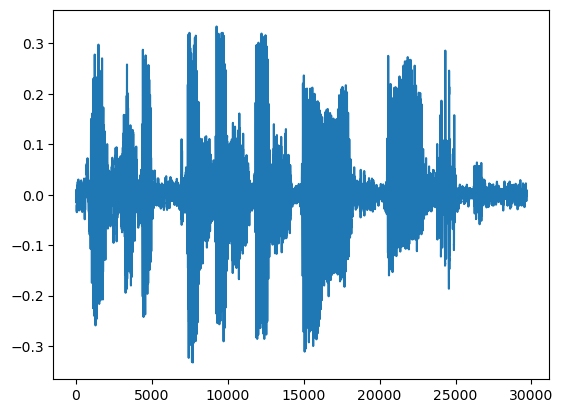

In [3]:

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import IPython.display as ipd

SR = 16000
CLIPS_DIR = Path(DATA_DIR) / "clips"

df = pd.read_csv(Path(DATA_DIR) / "dataset.csv")
df["sex"] = df["filename"].apply(lambda x: 'female' if int(x.split(".")[0].split("_")[-1]) else 'male')

test = df[df["split"] == "train"]

SAMPLE = test.iloc[0]
SAMPLE_PATH = CLIPS_DIR / SAMPLE['filename']

y, sr = librosa.load(SAMPLE_PATH, sr=SR)

print(f"Audio shape: {y.shape}, Sample rate: {sr}")
print(SAMPLE)
print(f"Audio duration: {len(y) / sr:.2f} seconds")

plt.plot(y)
ipd.Audio(SAMPLE_PATH)


- Analyze the proposed target metric (UAR): discuss its strengths, weaknesses, and potential edge cases. TIP: Check metrics from the next subsection: “Compare with the Dataset Author's work”

- Suggest complementary metrics to capture other aspects of performance.

- Propose an alternative target metric, with justification.

### Validation:
- Use native train/test split. Design a separate validation split from the train set
- Explain your motivation for the chosen strategy and the importance of balancing gender and emotion classes within the splits.
- Discuss the challenges of achieving balanced class distributions in naturalistic emotion datasets.

### Spectral Features (MelSpec, MFCC):
- Extract handcrafted acoustic features (e.g., MFCCs, Pitch/F0, RMS energy, Zero-Crossing Rate).
- Explore classical machine learning classifiers or simple neural networks to establish a baseline
for the 4-class emotion classification problem.
- Collect all relevant results:
- metrics (UAR, Accuracy, Macro F1)
- hard samples analysis (e.g., structural variations between neutral and sad, or angry and happy).
- Conclude whether acoustic features alone are adequate.
- Prepare an ablation study on the tested models

### Self-Supervised Approach (Data2Vec, Wave2Vec, …):
- Explore pre-trained self-supervised speech approaches, contrasting language-transfer models
(e.g., wav2vec2-xls-r-300m-uk) with task-transfer models (e.g., emotion2vec+).
- Collect all relevant results:
- metrics (focusing on Unweighted Average Recall)
- hard samples analysis.
- Conclude whether the model is adequate.
- Prepare an ablation study on the tested models, exploring freezing depths (e.g., number of frozen transformer blocks), loss functions (Focal Loss vs. Cross-Entropy), and data augmentation techniques.

### Compare with the Dataset Author's work
- Explore the approach proposed by Olha Havryluk
- Explain how your approach differs from baseline and why is it better

### Final Report
- Prepare a comprehensive report including:
- data insights,
- feature engineering,
- tried algorithms and models,
- chosen hyperparameters,
- metrics,
- insights and conclusions.
- Reports may be prepared in LaTeX or Markdown (README.md).